In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [16]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor
alpha = 0.15

# Evaluation parameters
max_steps_in_env = 200 # used for episodic evaluation


In [5]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V = np.zeros(num_states) # initialization for V(s)

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
for i in range(max_number_iterations):
    V_i = V.copy()
    d = 0
    for s in range(num_states):
        if (env.is_terminal_state(s)):
            continue
        R = []
        for a in ACTIONS:
            val = 0
            for p, sn in env.get_transition_distribution(s, a):
                r = env.reward(s, a, sn)
                val += p * (r + gamma * V[sn])
            R.append(val)
        V_i[s] = max(R)
        d = max(d, abs(V_i[s] - V[s]))

    V = V_i
    if d < threshold:
        print(f"Iterations count: {i}")
        break
# try looking at these functions' docs for inspiration

Iterations count: 33


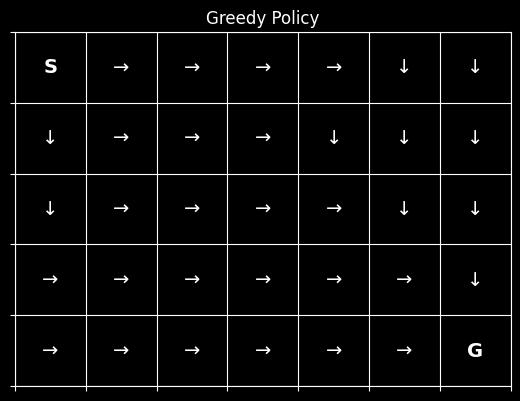

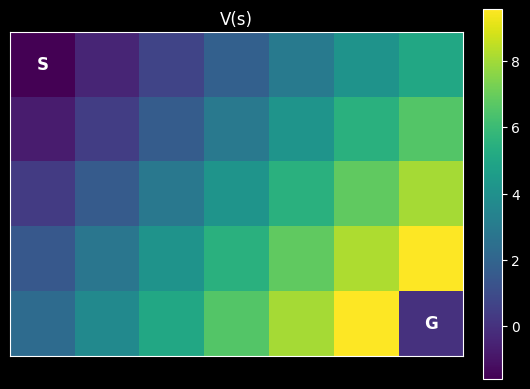

{'avg_return': -0.92, 'std_return': 1.9271, 'success_rate': 1.0, 'avg_steps': 11.92}


In [6]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# LAB 2

In [7]:
import random

In [8]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
num_actions = 4
num_elems = (num_states, num_actions)

Q = np.zeros(num_elems)

epsilon = 0.1

def eps_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    return np.argmax(Q[state])

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
for i in range(5000):
    X = random.randint(0, num_states - 2)
    X = env.reset()
    while not env.is_terminal_state(X):
        A = eps_greedy(X)
        X_prim, R, _, _ = env.step(A)
        Q[X][A] = Q[X][A] + alpha * (R + gamma * np.max(Q[X_prim]) - Q[X][A])
        X = X_prim

def get_states(state):
    return np.max(Q[state])

def greedy_policy(state):
    return int(np.argmax(Q[state]))

V = np.zeros(num_states)
for i in range(num_states):
    V[i] = get_states(i)

pi = np.zeros(num_states)
for i in range(num_states):
    pi[i] = greedy_policy(i)

# try looking at these functions' docs for inspiration

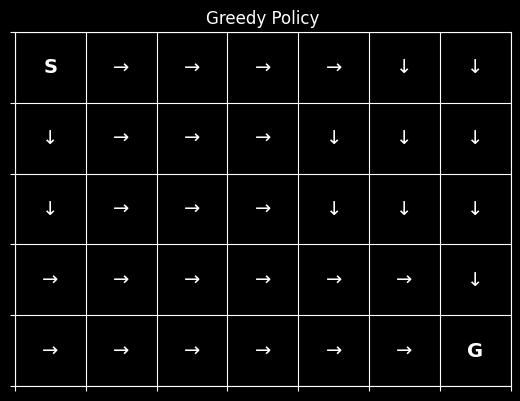

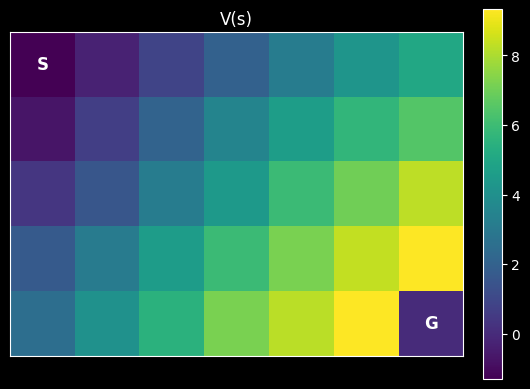

{'avg_return': -0.92, 'std_return': 1.9271, 'success_rate': 1.0, 'avg_steps': 11.92}


In [9]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)

# LAB 3

In [4]:
import random

In [17]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
num_actions = 4
num_elems = (num_states, num_actions)

Q = np.zeros(num_elems)

epsilon = 0.1

def eps_greedy(state):
    if random.random() < epsilon:
        return random.randint(0, 3)
    return np.argmax(Q[state])

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
for i in range(5000):
    X = env.reset()
    A = eps_greedy(X)
    while not env.is_terminal_state(X):
        X_prim, R, done, _ = env.step(A)
        if done:
            Q[X][A] = alpha * (R - Q[X][A])
            break
        A_prim = eps_greedy(X_prim)
        Q[X][A] = Q[X][A] + alpha * (R + gamma * Q[X_prim][A_prim] - Q[X][A])
        X = X_prim
        A = A_prim


def get_states(state):
    return np.max(Q[state])

def get_policy(state):
    return int(np.argmax(Q[state]))

V = np.zeros(num_states)
for i in range(num_states):
    V[i] = get_states(i)

pi = np.zeros(num_states)
for i in range(num_states):
    pi[i] = get_policy(i)

# try looking at these functions' docs for inspiration

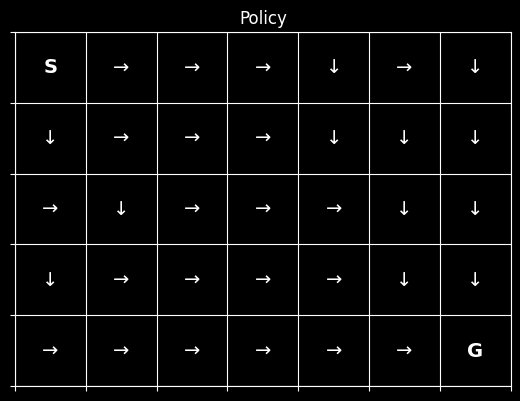

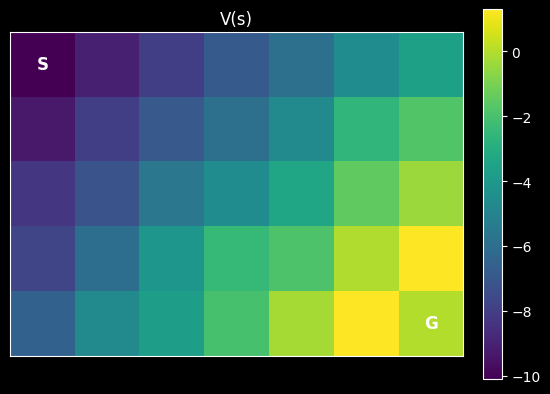

{'avg_return': -1.16, 'std_return': 2.1294, 'success_rate': 1.0, 'avg_steps': 12.16}


In [18]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)